# 04. Проверка на отложенной тестовой выборке

`data/test.csv` открываем **впервые**. Эти 20 % строк не участвовали ни в выборе признаков, ни в выборе модели, ни в подборе гиперпараметров.

Главная проверка воспроизводимости: в модель подаём тест **в сыром виде**, как он лежит в CSV (с `"Hectares "` с пробелом, со строковыми категориями). Ни одной строки предобработки в этом ноутбуке нет — вся цепочка внутри `best_model.joblib`.

In [1]:
from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.dummy import DummyRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_absolute_percentage_error,
    r2_score, root_mean_squared_error
)

from modules import plots
from modules.transformers import (
    TARGET, AREA_COL, CATEGORICAL_COLS, 
    PerHectareRegressor, clean_column_names
)

DATA_DIR = Path("data")
MODELS_DIR = Path("models")
plots.setup_style()

test_df = pd.read_csv(DATA_DIR / "test.csv")
model = joblib.load(MODELS_DIR / "best_model.joblib")
model_info = json.loads((MODELS_DIR / "model_info.json").read_text())

X_test, y_test = test_df.drop(columns=[TARGET]), test_df[TARGET]

## 1. Метрики

Сравниваем с тремя ориентирами:
* качество той же модели на valid: если на тесте сильно хуже, значит, модель подогнана под valid;
* бейзлайн «средняя урожайность с гектара по train × площадь»;
* **MAE на гектар**: ошибка, приведённая к одному гектару, сопоставима между маленькими и большими полями.

In [2]:
y_pred = model.predict(X_test)

train_df = pd.read_csv(DATA_DIR / "train.csv")
baseline = PerHectareRegressor(DummyRegressor()).fit(
    train_df.drop(columns=[TARGET]), 
    train_df[TARGET]
)
y_base = baseline.predict(X_test)

area = clean_column_names(X_test)[AREA_COL].to_numpy()


def metrics(y_true, y_hat):
    return {
        "MAE, кг": mean_absolute_error(y_true, y_hat),
        "RMSE, кг": root_mean_squared_error(y_true, y_hat),
        "MAPE, %": 100 * mean_absolute_percentage_error(y_true, y_hat),
        "R²": r2_score(y_true, y_hat),
        "MAE на гектар, кг/га": np.mean(np.abs(y_true - y_hat) / area)
    }


summary = pd.DataFrame({
    "модель, test": metrics(y_test, y_pred),
    "бейзлайн, test": metrics(y_test, y_base),
}).T
summary.loc["модель, valid (из 03)", ["MAE, кг", "RMSE, кг", "R²"]] = [
    model_info["valid"]["MAE"], model_info["valid"]["RMSE"], model_info["valid"]["R2"]]
summary.round(3)

,"MAE, кг","RMSE, кг","MAPE, %",R²,"MAE на гектар, кг/га"
"модель, test",656.265,912.756,2.873,0.990,169.017
"бейзлайн, test",990.942,1205.131,4.365,0.983,259.044
"модель, valid (из 03)",588.968,839.752,NaN,0.992,NaN


На тесте MAE выше, чем на valid. Это переобучение или просто другая выборка? Оценим неопределённость MAE бутстрэпом: 2 000 раз перевыбираем строки теста с возвращением.

In [3]:
abs_err = np.abs(y_test.to_numpy() - y_pred)
rng = np.random.default_rng(42)
boot = np.array([
    abs_err[rng.integers(0, len(abs_err), len(abs_err))].mean() 
    for _ in range(2000)
])
lo, hi = np.percentile(boot, [2.5, 97.5])
gain_test = 1 - summary.loc["модель, test", "MAE, кг"] / summary.loc["бейзлайн, test", "MAE, кг"]
gain_valid = 1 - model_info["valid"]["MAE"] / model_info["baseline_valid_mae"]
print(f"MAE на тесте: {abs_err.mean():.0f} кг, 95 % доверительный интервал [{lo:.0f}; {hi:.0f}]")
print(f"Выигрыш над бейзлайном: test {gain_test:.0%}, valid {gain_valid:.0%}")

MAE на тесте: 656 кг, 95 % доверительный интервал [600; 712]
Выигрыш над бейзлайном: test 34%, valid 37%


* **MAE = 656 кг (MAPE 2.9 %, 169 кг/га)** против 991 кг у бейзлайна: модель точнее на **34 %**.
* На valid было 589 кг, на CV 593 кг, то есть тест хуже примерно на 65 кг. Но это **не признак переобучения**:
  * **бейзлайн**, у которого нет гиперпараметров, на этих же строках тоже хуже на 50 кг (991 против 941). Тестовая выборка просто «труднее»;
  * относительный выигрыш над бейзлайном одинаков (34 % на тесте, 37 % на valid);
  * 95 % интервал для MAE на тесте ≈ [600; 712] кг — он практически стыкуется с оценкой CV (593 кг). Тест оказался на «невезучем» краю обычного разброса.

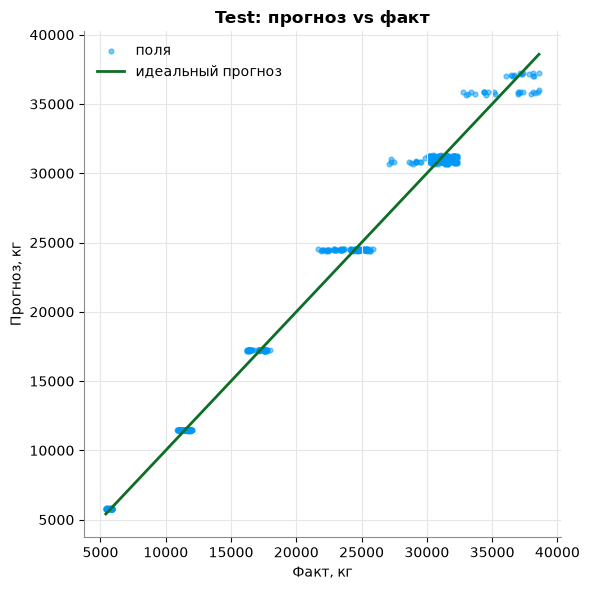

In [4]:
plots.plot_pred_vs_true(
    y_test, y_pred, title="Test: прогноз vs факт"
)

## 2. Анализ остатков

Остаток = факт − прогноз. У хорошей модели остатки:
1. в среднем около нуля (нет систематического сдвига);
2. не зависят от величины прогноза (гомоскедастичность);
3. не зависят от признаков (модель забрала всю доступную структуру).

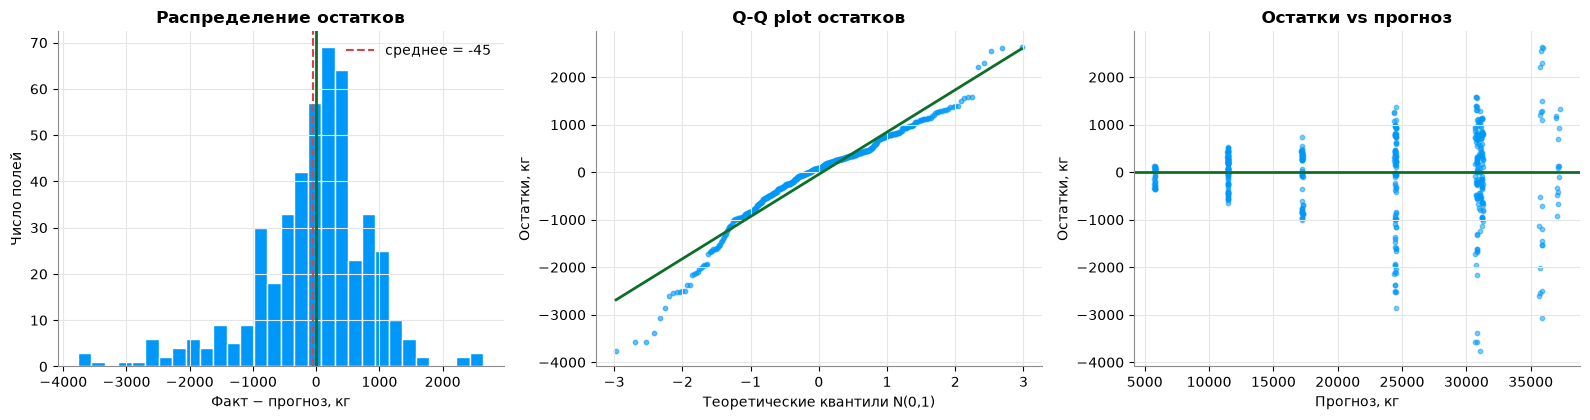

In [5]:
plots.plot_residual_diagnostics(y_test, y_pred)

* **Смещения почти нет:** средний остаток −45 кг (0.2 % от среднего урожая).
* **Распределение несимметрично, с тяжёлым левым хвостом** (Q-Q plot уходит вниз слева). Иногда модель сильно *переоценивает* урожай, на 2–4 т: это поля с неожиданно низким сбором, который по имеющимся признакам предсказать нельзя. Правый хвост короче: неожиданно высоких урожаев меньше.
* **Гетероскедастичность:** разброс остатков растёт с прогнозом, то есть с площадью поля (воронка на правом графике). Ошибка в кг пропорциональна площади, поэтому MAE и особенно RMSE в кг определяются в основном крупными полями.
* **Вертикальные полосы:** прогноз принимает немного разных значений. Модель по сути предсказывает средний урожай для каждой комбинации «площадь × сорт × …», потому что других различий между полями в данных нет.

Перейдём к остаткам **на гектар**, чтобы убрать эффект масштаба:

In [ ]:
resid = y_test.to_numpy() - y_pred
frame = clean_column_names(X_test)[[AREA_COL] + CATEGORICAL_COLS].assign(
    resid=resid, 
    resid_per_ha=resid / area
)

by_area = frame.groupby(AREA_COL).agg(
    полей=("resid", "size"),
    средний_остаток_кг=("resid", "mean"),
    MAE_кг=("resid", lambda r: r.abs().mean()),
    MAE_на_га=("resid_per_ha", lambda r: r.abs().mean()),
).round(1)
by_area

,полей,средний_остаток_кг,MAE_кг,MAE_на_га
Hectares,,,,
1,31,-87.5,161.9,161.9
2,89,54.0,272.4,136.2
3,58,-121.6,483.2,161.1
4,97,-225.3,876.6,219.1
5,157,32.3,744.1,148.8
6,36,15.7,1333.2,222.2


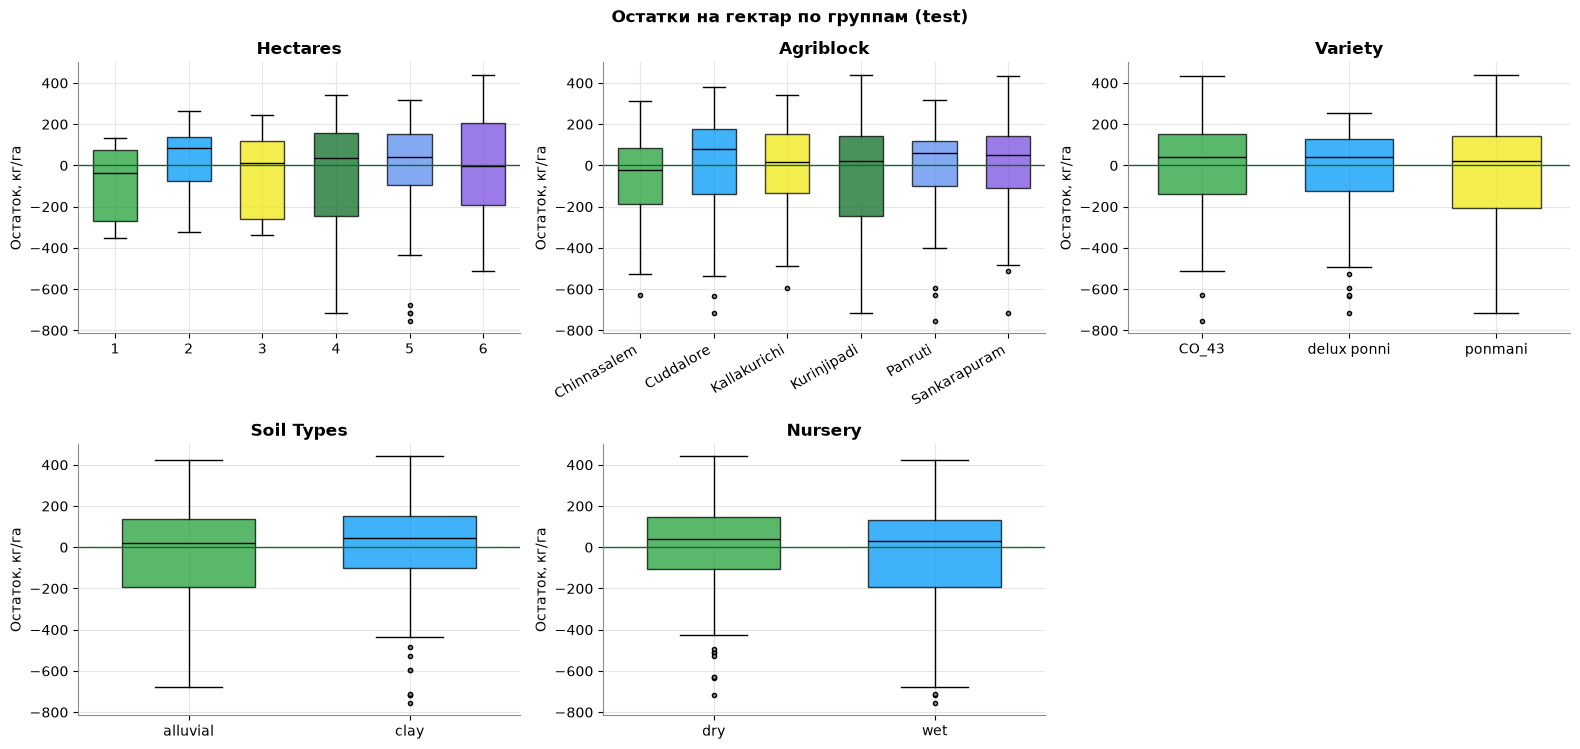

In [7]:
plots.plot_residuals_by_group(
    frame, "resid_per_ha", 
    [AREA_COL] + CATEGORICAL_COLS,
    ylabel="Остаток, кг/га", 
    title="Остатки на гектар по группам (test)"
)

* В кг ошибка растёт с площадью (162 кг для 1 га → 1 333 кг для 6 га), а **на гектар она примерно постоянна: 136–222 кг/га**.
* Больше всего ошибок у полей 4 и 6 га. В train у них самый широкий разброс урожайности (std ≈ 260–270 кг/га против 160–175 у остальных), то есть эти группы просто шумнее.
* У полей 4 га на тесте есть небольшое смещение: модель в среднем переоценивает на ≈ 56 кг/га. При 97 полях это ≈ 2 стандартные ошибки — стоит следить, но выводов на одной выборке не делаем.
* **Медианы остатков по агроблокам, сортам, почвам и питомникам ≈ 0.** Систематических перекосов нет: модель забрала из этих признаков всю структуру, которую видно.

## 3. Сколько ещё можно выжать из этих признаков?

В train много полей с **полностью одинаковыми** признаками (площадь, блок, сорт, почва, питомник), но разной урожайностью. Разброс внутри таких групп никакая модель на этих признаках не объяснит: для неё это один и тот же объект. Оценим этот разброс по группам, где не меньше 5 полей.

In [8]:
tr = clean_column_names(train_df)
keys = [AREA_COL] + CATEGORICAL_COLS
tr["y_per_ha"] = tr[TARGET] / tr[AREA_COL]
grp = tr.groupby(keys)["y_per_ha"]
big = tr[grp.transform("size") >= 5]
floor_per_ha = (big["y_per_ha"] - big.groupby(keys)["y_per_ha"].transform("median")).abs().mean()

print(f"Групп с ≥5 одинаковыми полями: {big.groupby(keys).ngroups}, в них {len(big)} полей из {len(tr)}")
print(f"Неустранимый разброс внутри групп ≈ {floor_per_ha:.0f} кг/га")
print(f"Ошибка модели на тесте          = {summary.loc['модель, test', 'MAE на гектар, кг/га']:.0f} кг/га")
print(f"Ошибка бейзлайна на тесте       = {summary.loc['бейзлайн, test', 'MAE на гектар, кг/га']:.0f} кг/га")

Групп с ≥5 одинаковыми полями: 175, в них 1264 полей из 1870
Неустранимый разброс внутри групп ≈ 140 кг/га
Ошибка модели на тесте          = 169 кг/га
Ошибка бейзлайна на тесте       = 259 кг/га


## 4. Проверка «как в проде»

Новое поле: неизвестный модели агроблок и новый сорт. Пайплайн не должен падать.

In [9]:
new_field = X_test.head(1).copy()
new_field["Agriblock"] = "Vriddhachalam"     # нет в train
new_field["Variety"] = "IR_64"               # нет в train
print(f"Прогноз для нового поля ({new_field['Hectares '].item()} га): {model.predict(new_field)[0]:,.0f} кг")
print(f"Прогноз для исходной строки:            {model.predict(X_test.head(1))[0]:,.0f} кг")

Прогноз для нового поля (5 га): 31,032 кг
Прогноз для исходной строки:            30,839 кг


Пайплайн не упал. Неизвестные категории обнулились в one-hot, прогноз остался разумным: он определяется площадью. Это поведение `handle_unknown="ignore"`.

## Выводы

**Пайплайн.** Вся цепочка — очистка имён колонок, кодирование, масштабирование, модель — лежит в одном `best_model.joblib` и применяется к сырому `test.csv`. Тест не участвовал ни в одном решении, поэтому его оценка честная.

**Качество.**

| | MAE, кг | MAE, кг/га | MAPE |
|---|---|---|---|
| бейзлайн «среднее/га × площадь» | 991 | 259 | 4.4 % |
| GradientBoosting (pipeline) | **656** | **169** | **2.9 %** |

Модель на треть точнее агрономического правила и близка к пределу того, что можно извлечь из этих признаков.

**Остатки.** Без систематического смещения по группам, но гетероскедастичны (ошибка ∝ площади) и с тяжёлым левым хвостом (редкие неурожаи модель не видит).

## Что лучше сделать дальше

1. **Перейти к метрикам на гектар или в процентах.** Из-за гетероскедастичности MAE в кг «принадлежит» крупным полям. Для сравнения моделей удобнее MAE на гектар или MAPE.
2. **Давать интервал, а не точку.** Для планирования важно знать «нижнюю границу» урожая, особенно с учётом левого хвоста. Подойдет квантильный бустинг (`loss="quantile"`).
3. **Рассмотреть `Ridge (на гектар)` как прод-вариант.** На CV он отстаёт от бустинга на ≈ 15 кг (в пределах разброса по фолдам), зато его коэффициенты напрямую читаются как «+N кг/га за сорт / размер поля».
4. **Разобраться с происхождением данных.** 16 % точных дубликатов, нормы, строго пропорциональные площади, и погода «на блок» похожи на синтетически расширенный набор. Перед выводами для реального хозяйства это стоит уточнить у авторов датасета.